# 2. Distributed Methods

Contents
1. Word2vec
2. FastText
3. Glove
4. Visualization

## Prepare for the practice session

### The files uploaded to Colab

* `NanumBarunpenB.otf` : Font used to prevent text from being broken during visualization
* `wordsim_similarity_goldstandard.csv` : Word similarity test data
* `word_analogy_goldstandard.txt` : Semantic word analogy test data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import Libraries

In [ ]:
!pip install gensim

WARNING: The following packages were previously imported in this runtime:
  [numpy]
You must restart the runtime in order to use newly installed versions.

Please re-run the cells from this point onwards.

In [ ]:
# Import the necessary libraries
import gensim
from gensim.models import Word2Vec, FastText
from gensim.models import KeyedVectors
import pandas as pd

* Gensim Library - [What is Gensim?](https://radimrehurek.com/gensim/intro.html)
  * Gensim is a library that provides the necessary tools to represent text data as meaningful vectors.
  Through Gensim, you can use algorithms such as Word2Vec and FastText.

### Load Corpus Data

In [ ]:
import nltk
nltk.download('movie_reviews')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
import nltk
from nltk.corpus import movie_reviews

# Download the movie_reviews dataset from NLTK
nltk.download('movie_reviews')

# Fetch review texts as a list
reviews = [' '.join(movie_reviews.words(fileid)) for fileid in movie_reviews.fileids()]

# Enclose each review in double quotes and separate them with new lines
reviews_str = '\n'.join([f'"{review}"' for review in reviews])

# Save the transformed review strings to a text file
with open('movie_reviews.txt', 'w', encoding='utf-8') as f:
    f.write(reviews_str)

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


In [ ]:
path = '/content/movie_reviews.txt'

### 1) Word2Vec

* This is a word embedding model introduced by Google's research team in 2013, and it is one of the most widely used models.
* Two training methods of the Word2Vec model:
    * **CBOW Model**: Trained by predicting the target word using the context words.
    * **Skip-gram Model**: Trained by predicting the surrounding context words using the target word.
<img src="https://blog.kakaocdn.net/dn/Czgg5/btqEttXkz91/LK5RqukCujicrxQ2kRWt0k/img.png" height=300>
* [Gensim API Reference - Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html)

#### Training the Word2Vec Model

In [ ]:
# Convert the data into a suitable object to be used as input for the model
corpus = gensim.models.word2vec.Text8Corpus(path)

print(list(corpus)[0][:100])

['"plot', ':', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', ',', 'drink', 'and', 'then', 'drive', '.', 'they', 'get', 'into', 'an', 'accident', '.', 'one', 'of', 'the', 'guys', 'dies', ',', 'but', 'his', 'girlfriend', 'continues', 'to', 'see', 'him', 'in', 'her', 'life', ',', 'and', 'has', 'nightmares', '.', 'what', "'", 's', 'the', 'deal', '?', 'watch', 'the', 'movie', 'and', '"', 'sorta', '"', 'find', 'out', '.', '.', '.', 'critique', ':', 'a', 'mind', '-', 'fuck', 'movie', 'for', 'the', 'teen', 'generation', 'that', 'touches', 'on', 'a', 'very', 'cool', 'idea', ',', 'but', 'presents', 'it', 'in', 'a', 'very', 'bad', 'package', '.', 'which', 'is', 'what', 'makes', 'this', 'review', 'an', 'even', 'harder', 'one', 'to']


In [ ]:
# Train the Word2Vec model using the loaded data (corpus)
model = Word2Vec(sentences=corpus, window=3, min_count=5, sg=1)

* `sentences`: A list of word lists (a list of lists of tokens)
* `size`: The dimensionality of the embedding vectors
* `window`: The number of words (range) to look at before and after the target word for prediction
* `min_count`: Determines the minimum frequency of words to be ignored
* `sg`: Training algorithm. 1 - Skip-gram, 0 - CBOW

#### Check the Word2Vec Embedding Results

In [ ]:
# Save the word vectors obtained from the trained model
word2vec_vectors = model.wv
word2vec_vectors.save("word2vec.wordvectors")

del model

In [ ]:
# Let's check the dense vector corresponding to 'bad'
word2vec_vectors['actor'] # A word present in the corpus

array([ 0.21178938,  0.0394794 ,  0.22688273, -0.6101197 ,  0.33376202,
       -0.46740073,  0.49958554,  0.4319002 ,  0.53199065, -0.0871309 ,
        0.41536182, -0.10784256,  0.01520506,  0.35667673, -0.37079507,
        0.21309024,  0.06283961, -0.1223017 ,  0.34719816, -0.27207008,
        0.33530214,  0.6681406 , -0.00957789,  0.02583865,  0.17377792,
        0.5738559 ,  0.52839094,  0.04956266, -0.4617867 , -0.0363629 ,
        0.11755999, -0.04929756,  0.27837744, -0.51605123,  0.25202477,
        0.1354319 ,  0.14285097, -0.4510617 , -0.6028028 ,  0.02498035,
       -0.03609145, -0.389134  , -0.39245513,  0.09740265,  0.23260622,
        0.01611178, -0.53052145, -0.09895897, -0.00522972,  0.17652246,
       -0.44000754, -0.3570524 ,  0.33696565,  0.36760905, -0.29608002,
        0.21411754,  0.32582408,  0.2948674 , -0.2818121 ,  0.19290143,
       -0.05663285, -0.39310613,  0.10820205, -0.09382267,  0.09068159,
        0.66575265, -0.37138754,  0.38026664, -0.15221596,  0.09

#### Evaluating Word2Vec Embeddings

In [ ]:
# Load the previously saved word vectors
word2vec_vectors = KeyedVectors.load("word2vec.wordvectors")

##### Output the Most Similar Words

In [ ]:
# Print the 10 most similar words to 'bad'
word2vec_vectors.most_similar('actor', topn=10)

[('actress', 0.8266297578811646),
 ('nomination', 0.7292664051055908),
 ('performer', 0.7125150561332703),
 ('villain', 0.7110928297042847),
 ('award', 0.6899417042732239),
 ('underrated', 0.6891338229179382),
 ('winner', 0.6886168718338013),
 ('performance', 0.6861872673034668),
 ('starred', 0.6825369596481323),
 ('comedian', 0.6813343167304993)]

In [ ]:
# An error occurs if the word does not exist in the corpus
word2vec_vectors.most_similar('hanyang', topn=10)

KeyError: "Key 'hanyang' not present in vocabulary"

##### Calculate Similarity Between Two Words

In [ ]:
# Similarity between 'bad' and 'hockey'
word2vec_vectors.similarity('bad', 'actor')

np.float32(0.28524172)

In [ ]:
# Similarity between 'good' and 'hockey'
word2vec_vectors.similarity('good', 'actor')

np.float32(0.29362062)

##### Print the Least Similar Words

In [ ]:
# Print the word that is least similar among 'comedy', 'drama', and 'thriller'
word2vec_vectors.doesnt_match(['comedy', 'drama', 'thriller'])

'comedy'

##### Operations on Word Vectors

In [ ]:
# actress + female - male = ???
word2vec_vectors.most_similar(positive=['actress', 'female'], negative=['male'], topn=5)

[('actor', 0.7051761150360107),
 ('role', 0.6644688844680786),
 ('villain', 0.6509798765182495),
 ('performer', 0.6358792185783386),
 ('nomination', 0.6291506290435791)]

### 2) FastText

* A word embedding technique developed and released by Facebook.
* It is fundamentally similar to word2vec, but represents each word as character (character-level) n-grams.
* FastText considers that multiple words exist within a single word and learns by taking internal words, or subwords, into account.
* It has the advantage of being able to handle unknown words (Out Of Vocabulary) that are not in the corpus.
* [Gensim API Reference - FastText](https://radimrehurek.com/gensim/models/fasttext.html)

#### Training the FastText Model

In [ ]:
# Train the FastText model using the loaded data (corpus)
model = FastText(sentences=corpus, window=3, min_count=5, sg=1)

* `sentences`: A list of word lists (a list of lists of tokens)
* `size`: The dimensionality of the embedding vectors
* `window`: The number of characters (range) to look at before and after the target word for prediction
* `min_count`: Determines the minimum frequency of words to be ignored
* `sg`: Training algorithm. 1 - Skip-gram, 0 - CBOW

#### Check the FastText Embedding Results

In [ ]:
# Save the word vectors obtained from the trained model
FastText_vectors = model.wv
FastText_vectors.save("fasttext.wordvectors")

del model

In [ ]:
# Let's check the dense vector corresponding to 'actor'
FastText_vectors['actor']

array([ 1.7420560e-01, -1.9179644e-01, -2.7342236e-01,  1.0430435e-01,
        6.9235608e-02, -3.9038247e-01, -2.3451176e-01,  3.4321821e-01,
       -2.7612445e-01, -6.1989117e-01,  5.9842718e-01,  7.1817505e-01,
       -1.8095728e-02,  9.2767268e-02,  1.3972269e-01,  1.9624871e-01,
       -2.3379806e-02, -3.3015555e-01, -5.6294364e-01, -2.2510394e-01,
       -2.2784662e-01,  3.3061388e-01,  2.8940526e-01,  5.3460145e-01,
       -1.6612633e-01,  4.1835397e-01, -7.7561863e-02, -2.3159413e-01,
        4.4344465e-04, -3.8125470e-01, -1.4241685e-01, -1.2571543e-01,
        3.0768934e-01, -3.1519026e-01, -2.7324778e-01,  2.1980067e-01,
        3.3351415e-01, -6.0044676e-01, -5.1803005e-01,  5.3513843e-01,
        1.6129541e-01,  1.9297336e-01, -5.4168576e-01,  8.1166625e-01,
        3.0616027e-01, -4.0711591e-01, -2.1765899e-02, -3.5663888e-01,
        8.8663034e-02, -3.7092844e-03,  2.9434234e-01, -1.0124482e-01,
        8.4678732e-02,  2.8152698e-01, -7.6279528e-02,  1.0023932e-01,
      

#### Evaluating FastText Embeddings

In [ ]:
# Load the previously saved word vectors
FastText_vectors = KeyedVectors.load("fasttext.wordvectors")

##### Output the Most Similar Words

In [ ]:
FastText_vectors.most_similar('actor', topn=10)

[('factor', 0.870453953742981),
 ('actress', 0.8675429821014404),
 ('benefactor', 0.8191649913787842),
 ('performer', 0.7825614213943481),
 ('hector', 0.7747710347175598),
 ('actresses', 0.7738139629364014),
 ('actors', 0.7462213039398193),
 ('doctor', 0.744593620300293),
 ('inspector', 0.7318247556686401),
 ('perlman', 0.7194779515266418)]

**❓Why can FastText represent OOV words better than Word2Vec?**

FastText composes word vectors from character n-gram subwords, so unseen words still get representations via their subparts.

In [ ]:
# Similarity can be calculated even for words not present in the corpus
FastText_vectors.most_similar('hanyang', topn=10) # Word2Vec과는 다르게, 안 나온 단어도 유사도 측정 가능!

[('hanako', 0.9141737222671509),
 ('zhang', 0.913651168346405),
 ('harmony', 0.8929029703140259),
 ('yang', 0.8922667503356934),
 ('tiffany', 0.8877188563346863),
 ('shang', 0.8875941634178162),
 ('wolfgang', 0.8813179135322571),
 ('hang', 0.8812161684036255),
 ('handheld', 0.8807761669158936),
 ('peckinpah', 0.8806049227714539)]

##### Similarity Analysis Between Two Words

In [ ]:
FastText_vectors.similarity('bad', 'actor')

np.float32(0.3395509)

In [ ]:
FastText_vectors.similarity('good', 'actor')

np.float32(0.33478156)

### 3) GloVe
* A word embedding technique developed by a research team at Stanford University.
* It is designed to reflect global statistical information, rather than just learning local context within a window, while still providing good performance in similarity calculations.
* It uses a word-context matrix (co-occurrence matrix).

  * "What do you want to eat today?"
  * "I want to eat salmon today."
  * "I ate salmon yesterday."

| Count | Today | What | Eat | Want | I | Salmon | Yesterday | Ate |
|-------|-------|------|-----|------|---|--------|-----------|-----|
| Today | 0     | 1    | 0   | 0    | 1 | 1      | 0         | 0   |
| What  | 1     | 0    | 1   | 0    | 0 | 0      | 0         | 0   |
| Eat   | 0     | 1    | 0   | 2    | 0 | 1      | 0         | 0   |
| Want  | 0     | 0    | 2   | 0    | 0 | 0      | 0         | 0   |
| I     | 1     | 0    | 0   | 0    | 0 | 0      | 1         | 0   |
| Salmon | 1    | 0    | 1   | 0    | 0 | 0      | 1         | 1   |
| Yesterday | 0 | 0    | 0   | 0    | 1 | 1      | 0         | 0   |
| Ate   | 0     | 0    | 0   | 0    | 0 | 1      | 0         | 0   |

* [GloVe Python GitHub](https://github.com/maciejkula/glove-python)

#### Install Required Libraries

In [ ]:
# Install mittens library (GloVe implementation)
!pip install mittens

In [ ]:
# Import necessary libraries
import numpy as np
from mittens import GloVe
from collections import defaultdict, Counter
import gensim
from scipy.sparse import dok_matrix
import gc

In [ ]:
# Download Text8 dataset
import gensim.downloader as api

print("Downloading Text8 corpus...")
print("This may take a few minutes on first run...")
print("=" * 50)

# Download the text8 dataset (about 31MB)
corpus = api.load('text8')

# Convert to list of sentences
data = list(corpus)

print("=" * 50)
print(f'Number of sentences: {len(data)}')
print(f'First sentence (first 10 words): {data[0][:10]}...')

This may take a few minutes on first run...
Number of sentences: 1701
First sentence (first 10 words): ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against']...


In [ ]:
# 전체 코드를 더 작은 vocabulary로 재실행
def build_cooccur_matrix_small(sentences, window_size=3, min_count=100, max_vocab=2000):
    """매우 작은 vocabulary로 matrix 생성"""
    word_counter = Counter()
    for sentence in sentences:
        word_counter.update(sentence)

    # 상위 2000개 단어만 사용
    top_words = [word for word, _ in word_counter.most_common(max_vocab)
                 if word_counter[word] >= min_count]
    vocab = set(top_words)
    word2id = {word: idx for idx, word in enumerate(sorted(vocab))}

    print(f'Vocabulary size: {len(vocab)}')

    cooccur = defaultdict(float)
    for sent_idx, sentence in enumerate(sentences):
        sentence = [w for w in sentence if w in vocab]

        for i, word in enumerate(sentence):
            start = max(0, i - window_size)
            end = min(len(sentence), i + window_size + 1)

            for j in range(start, end):
                if i != j:
                    context_word = sentence[j]
                    distance = abs(i - j)
                    cooccur[(word2id[word], word2id[context_word])] += 1.0 / distance

        if (sent_idx + 1) % 100 == 0:
            print(f'Processed {sent_idx + 1}/{len(sentences)} sentences')

    return cooccur, word2id

# 재구성
print("\nBuilding smaller co-occurrence matrix...")
cooccur_dict, word2id = build_cooccur_matrix_small(
    data,
    window_size=3,
    min_count=100,      # 더 높은 threshold
    max_vocab=2000      # 더 작은 vocabulary
)

print(f'Co-occurrence pairs: {len(cooccur_dict)}')

# Convert to dense directly
vocab_size = len(word2id)
cooccur_dense = np.zeros((vocab_size, vocab_size), dtype=np.float32)

print("\nBuilding dense co-occurrence matrix...")
for (i, j), count in cooccur_dict.items():
    cooccur_dense[i, j] = count

del cooccur_dict
gc.collect()

print(f'Dense matrix shape: {cooccur_dense.shape}')

# Train GloVe
print("\nTraining GloVe model...")
print("=" * 50)

glove_model = GloVe(
    n=50,
    max_iter=10,
    learning_rate=0.05,
    display_progress=1
)

embeddings = glove_model.fit(cooccur_dense)

print("=" * 50)
print(f'Training completed!')
print(f'Embeddings shape: {embeddings.shape}')


Building smaller co-occurrence matrix...
Vocabulary size: 2000
Processed 100/1701 sentences
Processed 200/1701 sentences
Processed 300/1701 sentences
Processed 400/1701 sentences
Processed 500/1701 sentences
Processed 600/1701 sentences
Processed 700/1701 sentences
Processed 800/1701 sentences
Processed 900/1701 sentences
Processed 1000/1701 sentences
Processed 1100/1701 sentences
Processed 1200/1701 sentences
Processed 1300/1701 sentences
Processed 1400/1701 sentences
Processed 1500/1701 sentences
Processed 1600/1701 sentences
Processed 1700/1701 sentences
Co-occurrence pairs: 2537575

Building dense co-occurrence matrix...
Dense matrix shape: (2000, 2000)

Training GloVe model...


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Iteration 11: loss: 338479.59375

Training completed!
Embeddings shape: (2000, 50)


In [ ]:
def most_similar(word, embeddings, word2id, id2word, topn=10):
    """
    Find the most similar words to a given word.

    Parameters:
    - word: target word
    - embeddings: trained word embeddings
    - word2id: word to index mapping
    - id2word: index to word mapping
    - topn: number of similar words to return

    Returns:
    - List of (word, similarity_score) tuples
    """

    # Check if word exists in vocabulary
    if word not in word2id:
        return f"'{word}' is not in the vocabulary."

    # Get word vector
    word_idx = word2id[word]
    word_vec = embeddings[word_idx]

    # Calculate cosine similarity with all words
    # cosine_sim = dot(A, B) / (norm(A) * norm(B))
    similarities = np.dot(embeddings, word_vec) / (
        np.linalg.norm(embeddings, axis=1) * np.linalg.norm(word_vec)
    )

    # Get top N most similar words (excluding the word itself)
    top_indices = np.argsort(similarities)[::-1][1:topn+1]

    return [(id2word[idx], similarities[idx]) for idx in top_indices]

In [ ]:
# 1. id2word 딕셔너리 생성
id2word = {idx: word for word, idx in word2id.items()}
print(f"Created id2word mapping with {len(id2word)} words")

# 2. most_similar 함수 정의
def most_similar(word, embeddings, word2id, id2word, topn=10):
    """
    주어진 단어와 가장 유사한 단어들을 찾습니다.
    코사인 유사도를 사용합니다.
    """
    if word not in word2id:
        print(f"Warning: '{word}' not in vocabulary")
        return []

    # 대상 단어의 embedding
    word_idx = word2id[word]
    word_vec = embeddings[word_idx]

    # 모든 단어들과의 코사인 유사도 계산
    # cosine similarity = dot(A, B) / (||A|| * ||B||)
    norms = np.linalg.norm(embeddings, axis=1)
    word_norm = np.linalg.norm(word_vec)

    # 유사도 계산
    similarities = np.dot(embeddings, word_vec) / (norms * word_norm + 1e-10)

    # 자기 자신 제외하고 상위 topn개 추출
    similar_indices = np.argsort(similarities)[::-1]

    results = []
    for idx in similar_indices:
        if idx != word_idx and len(results) < topn:
            results.append((id2word[idx], similarities[idx]))

    return results

print("Functions defined successfully!")
print("=" * 50)

Created id2word mapping with 2000 words
Functions defined successfully!


In [ ]:
# Find words similar to 'actor'
print("Words most similar to 'actor':")
print("=" * 50)

results = most_similar('actor', embeddings, word2id, id2word, topn=10)

for i, (word, similarity) in enumerate(results, 1):
    print(f'{i:2d}. {word:15s} : {similarity:.6f}')

Words most similar to 'actor':
 1. actress         : 0.984861
 2. writer          : 0.982105
 3. politician      : 0.981891
 4. born            : 0.981530
 5. robert          : 0.979755
 6. singer          : 0.979251
 7. deaths          : 0.979129
 8. james           : 0.978640
 9. composer        : 0.978371
10. george          : 0.976874


In [ ]:
# Save the trained embeddings and mappings
import pickle

# Save embeddings
np.save('glove_embeddings.npy', embeddings)

# Save word mappings
with open('word2id.pkl', 'wb') as f:
    pickle.dump(word2id, f)

with open('id2word.pkl', 'wb') as f:
    pickle.dump(id2word, f)

print("Model saved successfully!")
print("Files created:")
print("  - glove_embeddings.npy")
print("  - word2id.pkl")
print("  - id2word.pkl")

Model saved successfully!
Files created:
  - glove_embeddings.npy
  - word2id.pkl
  - id2word.pkl


## Part 2 Visualization

* Visualize the word2vec embedding results.
* Since the embedding vectors are 100-dimensional, we need to reduce them to a lower dimension (2D or 3D) that we can understand for visualization.
* t-SNE (t-distributed Stochastic Neighbor Embedding)
  * A methodology to preserve the distances between words as much as possible during dimensionality reduction.
  * It iteratively adjusts the vector space to minimize the difference between the probability distribution of the data in the original space and that in the reduced space.

* [Reference for t-SNE Concept and Usage](https://gaussian37.github.io/ml-concept-t_sne/)

In [ ]:
import nltk
import pandas as pd
from nltk.corpus import movie_reviews

# Download the movie_reviews dataset from NLTK
nltk.download('movie_reviews')

# Get the file IDs and the corresponding categories (positive/negative labels)
fileids = movie_reviews.fileids()
categories = [movie_reviews.categories(fileid)[0] for fileid in fileids]

# Retrieve the text of each review by joining the words into a single string
reviews = [' '.join(movie_reviews.words(fileid)) for fileid in fileids]

# Convert the reviews and categories into a pandas DataFrame
df = pd.DataFrame({
    'review': reviews,
    'category': categories
})

# Access and print the first review and its label
print(df.iloc[0]['review'])
print(df.iloc[0]['category'])

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


plot : two teen couples go to a church party , drink and then drive . they get into an accident . one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . what ' s the deal ? watch the movie and " sorta " find out . . . critique : a mind - fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn ' t snag this one correctly . they seem to have taken this pretty neat concept , but executed it terribly . so what are the problems with the movie ? well , its main problem is that it ' s simply too jumbled . it starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience member , have no idea

In [ ]:
df.head()

,review,category
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard ' s quick movie review damn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' first...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


In [ ]:
import re
import nltk
from nltk import word_tokenize
nltk.download('punkt')
from collections import Counter

from sklearn.manifold import TSNE
import matplotlib.font_manager as fm
import matplotlib as mpl
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
# Handle the issue of broken minus signs in the graph fonts
mpl.rcParams['axes.unicode_minus'] = False

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources if necessary
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Define filters for special characters
FILTERS = "([~,!?\"':.;|~)^(])"  # Special characters to filter out
CHANGE_FILTER = re.compile(FILTERS)

# Define filter for numbers and dashes
EXP = "[1234567890\-]"  # Numbers and dashes to filter out
CHANGE_EXP = re.compile(EXP)

# Define filter to keep only English letters and spaces
ENG = "[^a-zA-Z\s]"  # Keep only letters and spaces
CHANGE_ENG = re.compile(ENG)

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Preprocess the reviews
words = []
for line in df['review']:
    line = CHANGE_FILTER.sub("", line)  # Remove special characters
    line = CHANGE_EXP.sub("", line)     # Remove numbers and dashes
    line = CHANGE_ENG.sub("", line)     # Remove everything that's not a letter or space
    line = line.strip()                  # Remove leading and trailing spaces
    if line:                             # Check if the line is not empty
        token = word_tokenize(line)      # Tokenize the cleaned line
        # Lemmatize and remove stopwords
        token = [lemmatizer.lemmatize(word.lower()) for word in token if word.lower() not in stop_words]
        words += token                   # Add tokens to the list

# Output the processed words
print(words)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Load the word2vec embedding results
word2vec_wordvectors = KeyedVectors.load('word2vec.wordvectors')

# Extract the 800 most frequent words
freq_list = Counter(words).most_common(800)
vocab = [i[0] for i in freq_list if len(i[0]) > 1]

# Filter for words that exist in the Word2Vec model
filtered_vocab = [word for word in vocab if word in word2vec_wordvectors.key_to_index]

# Embedding vectors corresponding to the filtered words
X = word2vec_wordvectors[filtered_vocab]

### t-SNE 2D Dimensionality Reduction

In [ ]:
# Create a t-SNE model to reduce to 2 dimensions
tsne_2d_model = TSNE(perplexity=15, n_components=2, max_iter=3600, random_state=0)

* `perplexity`: Controls the number of points that influence the learning process.

    Typically, values between 5 and 50 are used, and smaller values focus more on the local structure than the global structure.
* `n_components`: The dimensionality of the embedding space.
* `n_iter`: The maximum number of iterations for optimization. It should be at least 250.
* `random_state`: Sets the seed for the random number generation algorithm.  
* For more detailed explanations of the parameters, refer to [this link](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).

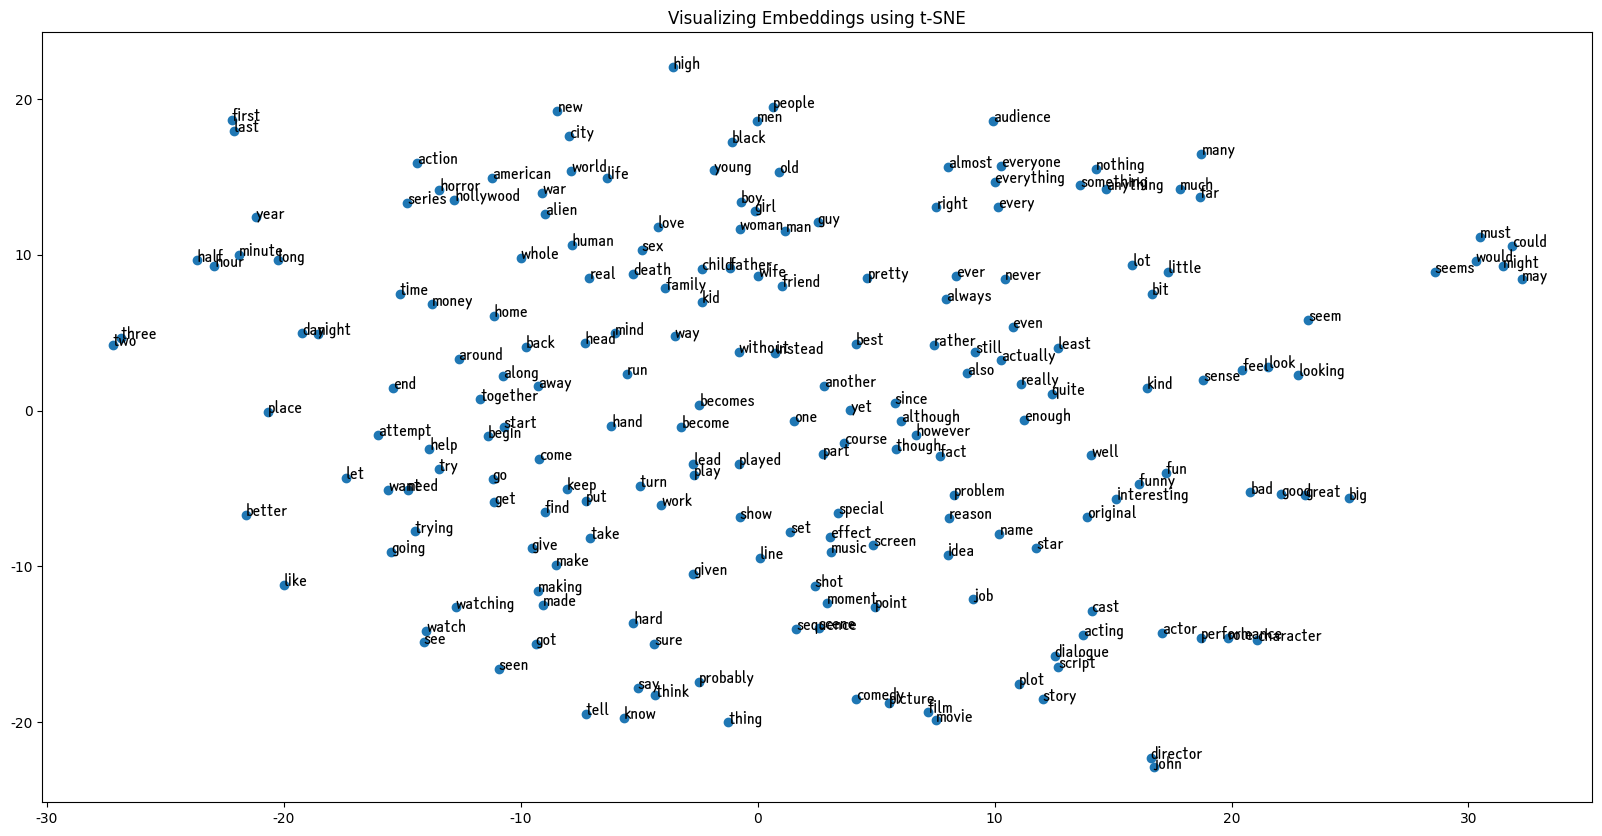

In [ ]:
from matplotlib import font_manager

# Define font properties
prop = font_manager.FontProperties(fname='/content/drive/MyDrive/Unstructured Data Analysis - Code Practice/[Week 6] Text Representation/data/NanumBarunpenB.otf')  # Path to the desired font file

def tsne_2d(title, tsne, X):
    # Reduce the embedding results from 100 dimensions to 2 dimensions
    X_tsne = tsne.fit_transform(X[:200,:])
    # Save the x and y coordinates for each word in a DataFrame
    df = pd.DataFrame(X_tsne, index=vocab[:200], columns=['x', 'y'])

    # Create and display the graph
    %matplotlib inline
    fig = plt.figure()              # Create the graph
    fig.set_size_inches(20, 10)     # Set graph size
    ax = fig.add_subplot(1, 1, 1)   # Create 2D axes
    ax.scatter(df["x"], df["y"])    # Mark points at each coordinate
    for word, pos in list(df.iterrows()):
        ax.annotate(word, pos, fontsize=12, fontproperties=prop) # Annotate words
    plt.title(title)                # Display title
    plt.show()                      # Output the graph

# tsne_2d_model must be defined
tsne_2d('Visualizing Embeddings using t-SNE', tsne_2d_model, X)

## 👀 [Reference] Word Embedding Test
* Quantitatively evaluate how well the grammatical and semantic relationships between words are captured in embeddings.

* Word similarity test
  * This method involves constructing a series of word pairs and calculating the correlation between human-evaluated scores and cosine similarity between word vectors to assess the quality of word embeddings.

* Word Analogy Evaluation
  * This evaluation tests whether answers to queries can be derived through calculations between word vectors.

In [ ]:
import seaborn as sns
import scipy.stats as st

### 1) Word Similarity Test

In [ ]:
# Returns the correlation between human-evaluated similarity scores of the evaluation data and the cosine similarity of the model's embedding vector pairs
def word_sim_test(test_fname, wordvectors):
        actual_sim_list, pred_sim_list = [], []
        missed = 0
        with open(test_fname, 'r') as pairs:
            for pair in pairs:
                w1, w2, actual_sim = pair.strip().split(",")
                try:
                    pred_sim = wordvectors.similarity(w1, w2)         # Cosine similarity between the model's embedding vector pairs
                    actual_sim_list.append(float(actual_sim))         # Human-evaluated similarity score
                    pred_sim_list.append(pred_sim)
                except KeyError:
                    missed += 1

        spearman, _ = st.spearmanr(actual_sim_list, pred_sim_list) # Spearman correlation coefficient
        pearson, _ = st.pearsonr(actual_sim_list, pred_sim_list)   # Pearson correlation coefficient
        return spearman, pearson, missed

In [ ]:
# This is the path to the test set.
test_fname = "/content/drive/MyDrive/Unstructured Data Analysis/[Week 5] Text Representation 1/data/wordsim_similarity_goldstandard.csv"

In [ ]:
# The Word2Vec and FastText embedding results (word vectors) learned previously are loaded here.
word2vec_wordvectors = KeyedVectors.load('word2vec.wordvectors')
fasttext_wordvectors = KeyedVectors.load('fasttext.wordvectors')

In [ ]:
# Perform word similarity evaluation for both models.
word2vec_test = word_sim_test(test_fname, word2vec_wordvectors)
fasttext_test = word_sim_test(test_fname, fasttext_wordvectors)

In [ ]:
# The closer the correlation coefficient is to 1, the stronger the correlation between the two.
# (spearman, pearson, missed)
print(word2vec_test)
print(fasttext_test)

(np.float64(0.07482103956584234), np.float64(0.11010294939732554), 70)
(np.float64(0.2517146600918461), np.float64(0.2851152204077942), 0)


In [ ]:
# The similarity evaluation results are output as a DataFrame.
df = pd.DataFrame({"Word Embedding": ["Word2Vec","Word2Vec","FastText","FastText"]})
df["Criterion"] = ["spearman", "pearson"]*2
df["score"] = list(word2vec_test[:-1] + fasttext_test[:-1])
df

,Word Embedding,Criterion,score
0,Word2Vec,spearman,0.074821
1,Word2Vec,pearson,0.110103
2,FastText,spearman,0.251715
3,FastText,pearson,0.285115


Text(0.5, 1.0, 'Word Similarity Test Result')

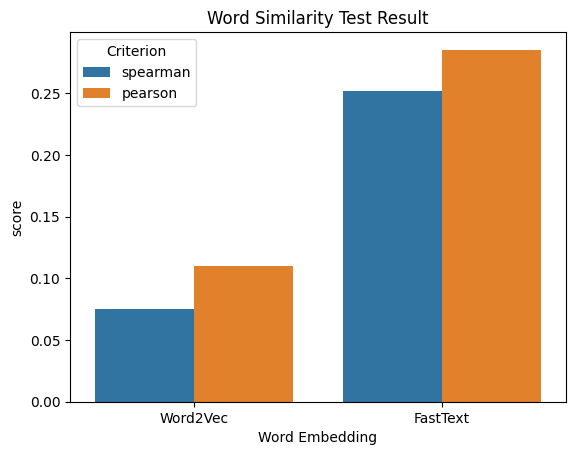

In [ ]:
# The similarity evaluation results are output as a bar plot.
sns.barplot(x="Word Embedding", y="score", hue="Criterion", data=df)
plt.title("Word Similarity Test Result")

### 2) Word Analogy Test

In [ ]:
# This function evaluates whether the result of vector arithmetic can deduce the correct answer in semantic analogy.
def word_analogy_test(test_fname, wordvectors):
        correct, total, missed = 0, 0, 0

        with open(test_fname, 'r', encoding='utf-8') as f:
            for line in f:
                if line.startswith("#") or len(line) <= 1: continue
                words = line.strip().split(" ")

                try:
                    predicted_answer = [i[0] for i in wordvectors.most_similar(positive=[words[0], words[2]], negative= [words[1]], topn=30)]
                    # print(words[0] + " - " + words[1] + " + " + words[2])
                    # print("correct answer:", words[3])
                    # print("predicted answers:", predicted_answer[0])
                    # print("")
                    if words[-1] in predicted_answer: correct += 1
                except:
                    missed += 1

                total += 1
        print(wordvectors)
        print("# of correct answer:", correct, ", # of data:", total, ", # of errors:", missed)
        print()
        return correct/(total-missed) # Correct count / Processed data count

In [ ]:
test_fname = "/content/drive/MyDrive/Unstructured Data Analysis/[Week 5] Text Representation 1/data/word_analogy_goldstandard.txt"

In [ ]:
# Perform word analogy evaluation for both models.
word2vec_test = word_analogy_test(test_fname, word2vec_wordvectors)
fasttext_test = word_analogy_test(test_fname, fasttext_wordvectors)

KeyedVectors<vector_size=100, 14848 keys>
# of correct answer: 198 , # of data: 19558 , # of errors: 13089

FastTextKeyedVectors<vector_size=100, 14848 keys>
# of correct answer: 1138 , # of data: 19558 , # of errors: 14



In [ ]:
# The analogy evaluation results are displayed as a DataFrame.
df2 = pd.DataFrame({"Word Embedding": ["Word2Vec","FastText"]})
df2["score"] = [word2vec_test, fasttext_test]
df2

,Word Embedding,score
0,Word2Vec,0.030608
1,FastText,0.058228


Text(0.5, 1.0, 'Word Analogy Test Result')

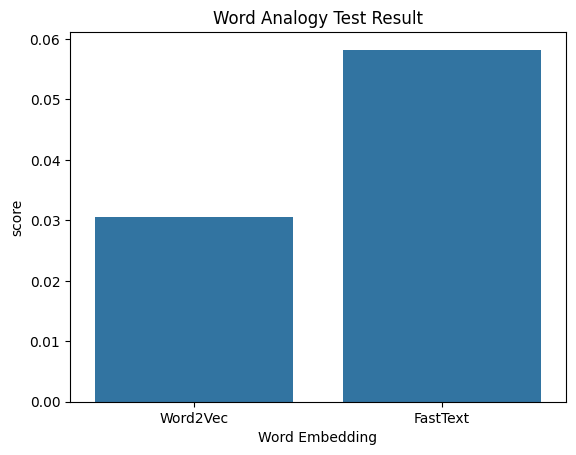

In [ ]:
# The analogy evaluation results are output as a bar plot.
sns.barplot(x="Word Embedding", y="score", data=df2)
plt.title("Word Analogy Test Result")